In [ ]:
import inspect
import json

import cmasher as cmr
import gc_utils
import h5py
import halo_analysis as halo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.interpolate import griddata, interp1d
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.stats import gaussian_kde, lognorm
from sklearn.svm import SVC, LinearSVC

# plt.rc("font", family="Nimbus Roman")
plt.rc("font", family="Nimbus Roman No9 L")

SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [ ]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]

min_mass = 10**4

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"

snap = 600

public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
timez0 = float(pub_data[pub_data["index"] == snap]["time_Gyr"].values[0])
pub_snaps = np.array(pub_data["index"])

all_data_fil = sim_dir + "/" + "m12i" + "/" + "m12i" + "_res7100/" + "snapshot_times.txt"
all_data = pd.read_table(all_data_fil, comment="#", header=None, sep=r"\s+")
all_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
all_times = np.array(all_data["time_Gyr"])
all_snaps = np.array(all_data["index"])

sim_codes = sim_dir + "simulation_codes.json"
with open(sim_codes) as sim_json:
    sim_data = json.load(sim_json)

grp_dict = {sim: None for sim in sim_lst}
for sim in sim_lst:
    grp_file = sim_dir + sim + "/" + "gc_groups.json"
    with open(grp_file, "r") as file:
        grp_col_dict = json.load(file)
    grp_lst = [int(grp) for grp in grp_col_dict[sim].keys() if int(grp) != 0]
    grp_dict[sim] = grp_lst

In [5]:
sim_dict = {}

# precompute snapshot times once
snap_times = {
    gc_utils.snapshot_name(snap): float(pub_data.loc[pub_data["index"] == snap, "time_Gyr"].values[0])
    for snap in pub_snaps
}

for sim in sim_lst:
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    sim_dict[sim] = {}

    with h5py.File(ghost_file, "r") as ghost_data:
        for it_id, it_grp in ghost_data.items():
            src = it_grp["source"]

            # ---- read once ----
            grpid = src["grpid"][()]
            amsk = grpid == 0

            logm_tfor = src["logm_tfor"][()]
            logm_tz0 = src["logm_tz0"][()]

            m_tfo = np.power(10.0, logm_tfor)
            m_tfo_ev = 0.55 * m_tfo

            m_tz0 = np.zeros_like(logm_tz0, dtype=float)
            msk = logm_tz0 != -1
            m_tz0[msk] = np.power(10.0, logm_tz0[msk])

            tfor = src["tfor"][()]
            tdis = src["tdis"][()]
            tacc = src["tacc"][()]
            feh = src["feh"][()]
            gcids = src["gcid"][()]

            tdis[tdis == -1] = np.inf
            # tacc[tacc == -1] = np.inf

            rz0 = np.linalg.norm(src["pxyz_snap600"][()], axis=1)

            # ---- vectorized ages ----
            age = timez0 - tfor
            age_p = np.where(tdis != -1, tdis - tfor, timez0 - tfor)

            t_tz0 = src["torb_600"][()]
            s_tz0 = src["s_flag"][()].astype(bool)
            sa_flag = src["sa_flag"][()].astype(bool)

            ml = m_tfo_ev - m_tz0
            ml_rate = ml / age_p

            # ---- snapshot mass table ----
            n_gc = len(gcids)
            n_snap = len(pub_snaps)

            mass_arr = np.full((n_gc, n_snap), np.nan, dtype=float)
            time_arr = np.full((n_gc, n_snap), np.nan, dtype=float)

            gcid_to_row = {g: i for i, g in enumerate(gcids)}

            for j, (snap_id, time) in enumerate(snap_times.items()):
                snp = it_grp["snapshots"][snap_id]

                snp_gcids = snp["gcid"][()]
                snp_mass = np.power(10.0, snp["logm"][()])

                # map snapshot gcids → indices in this iteration
                common, idx_snp, idx_src = np.intersect1d(snp_gcids, gcids, return_indices=True)

                mass_arr[idx_src, j] = snp_mass[idx_snp]
                time_arr[idx_src, j] = time

            m_tfo_msk = m_tfo >= min_mass

            sim_dict[sim][it_id] = {
                "m_tfo": m_tfo[m_tfo_msk],
                "m_tfo_ev": m_tfo_ev[m_tfo_msk],
                "m_tz0": m_tz0[m_tfo_msk],
                "tfor": tfor[m_tfo_msk],
                "tdis": tdis[m_tfo_msk],
                "tacc": tacc[m_tfo_msk],
                "age": age[m_tfo_msk],
                "age_p": age_p[m_tfo_msk],
                "t_tz0": t_tz0[m_tfo_msk],
                "s_tz0": s_tz0[m_tfo_msk],
                "ml": ml[m_tfo_msk],
                "ml_rate": ml_rate[m_tfo_msk],
                "acc": amsk[m_tfo_msk],
                "grp": grpid[m_tfo_msk],
                "feh": feh[m_tfo_msk],
                "rz0": rz0[m_tfo_msk],
                "gcid": gcids[m_tfo_msk],
                "m_snp": mass_arr[m_tfo_msk],
                "t_snp": time_arr[m_tfo_msk],
                "sa_flag": sa_flag[m_tfo_msk],
            }

In [6]:
def halo_mvir_history(halt, halo_tid0, slst):
    """Return Mvir(t) for a halo tracked over snapshots."""
    mvir = []
    for snp in slst:
        tid = gc_utils.get_halo_prog_at_snap(halt, halo_tid0, snp)
        idx = np.where(halt["tid"] == tid)[0][0]
        mvir.append(halt["mass.vir"][idx])
    return np.asarray(mvir)


def gc_counts_and_mass(tim, select, t_snp, m_snp):
    masses = []
    for i in np.where(select)[0]:
        x = t_snp[i]
        y = m_snp[i]
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() >= 2:
            masses.append(np.interp(tim, x[mask], y[mask]))
    return np.sum(select), np.nansum(masses)


def get_gc_prop(sim, sim_dict, grp_dict, halt, host_tid):
    """
    Compute GC count and mass evolution averaged over iterations,
    plus pre-accretion group properties and halo Mvir histories.
    """

    # --- shared time grid ---
    tlst_start = np.arange(2, 14, 0.5)
    idxs = np.abs(all_times[:, None] - tlst_start).argmin(axis=0)
    tlst = all_times[idxs]
    slst = all_snaps[idxs]

    # --- host halo virial-mass history ---
    host_mvir = halo_mvir_history(halt, host_tid, slst)

    it_ids = list(sim_dict[sim].keys())

    # ==========================================================================
    # ALL GCs (in MW)
    # ==========================================================================
    gccnts_all = []
    gcmass_all = []

    for it_id in it_ids:
        dat = sim_dict[sim][it_id]

        tfor = dat["tfor"]
        tdis = dat["tdis"].copy()
        tdis[tdis == -1] = np.inf
        tacc = dat["tacc"]

        t_snp = dat["t_snp"]
        m_snp = dat["m_snp"]

        cnt = np.zeros(len(tlst))
        mas = np.zeros(len(tlst))

        for k, tim in enumerate(tlst):
            alive = (tfor <= tim) & (tim < tdis)
            inmw = tacc <= tim
            select = alive & inmw

            cnt[k], mas[k] = gc_counts_and_mass(tim, select, t_snp, m_snp)

        gccnts_all.append(cnt)
        gcmass_all.append(mas)

    gccnts_all = np.asarray(gccnts_all)
    gcmass_all = np.asarray(gcmass_all)

    # averages over iterations
    gccnts_mean = gccnts_all.mean(axis=0)
    gccnts_std = gccnts_all.std(axis=0)
    gcmass_mean = gcmass_all.mean(axis=0)
    gcmass_std = gcmass_all.std(axis=0)

    # ==========================================================================
    # PRE‑ACCRETION GROUP PROPERTIES
    # ==========================================================================
    grp_props = {}

    for grp in grp_dict[sim]:
        grp_mvir = halo_mvir_history(halt, grp, slst)

        cnt_all = []
        mas_all = []

        for it_id in it_ids:
            dat = sim_dict[sim][it_id]

            tfor = dat["tfor"]
            tdis = dat["tdis"].copy()
            tdis[tdis == -1] = np.inf
            grps = dat["grp"]

            grp_msk = grps == grp
            if not np.any(grp_msk):
                continue

            tacc_grp = np.unique(dat["tacc"][grp_msk])[0]

            t_snp = dat["t_snp"]
            m_snp = dat["m_snp"]

            cnt = np.zeros(len(tlst))
            mas = np.zeros(len(tlst))

            for k, tim in enumerate(tlst):
                if tim > tacc_grp:
                    continue

                alive = (tfor <= tim) & (tim < tdis)
                select = alive & grp_msk

                cnt[k], mas[k] = gc_counts_and_mass(tim, select, t_snp, m_snp)

            cnt_all.append(cnt)
            mas_all.append(mas)

        if cnt_all:
            cnt_all = np.asarray(cnt_all)
            mas_all = np.asarray(mas_all)

            cnt_mean = cnt_all.mean(axis=0)
            cnt_std = cnt_all.std(axis=0)
            mas_mean = mas_all.mean(axis=0)
            mas_std = mas_all.std(axis=0)

            # replace zeros with NaN (pre-accretion periods)
            cnt_mean[cnt_mean == 0] = np.nan
            cnt_std[cnt_std == 0] = np.nan
            mas_mean[mas_mean == 0] = np.nan
            mas_std[mas_std == 0] = np.nan

            grp_props[grp] = {
                "mvir": grp_mvir,
                "cnt_avg": cnt_mean,
                "cnt_std": cnt_std,
                "mas_avg": mas_mean,
                "mas_std": mas_std,
            }

    # ==========================================================================
    # OUTPUT
    # ==========================================================================
    return {
        "time": tlst,
        "host": {
            "mvir": host_mvir,
            "cnt_avg": gccnts_mean,
            "cnt_std": gccnts_std,
            "mas_avg": gcmass_mean,
            "mas_std": gcmass_std,
        },
        "groups": grp_props,
    }


def get_gc_prop_origins(sim, sim_dict, halt, host_tid):
    """
    Compute GC count and mass evolution averaged over iterations,
    plus pre-accretion group properties and halo Mvir histories.
    """

    # --- shared time grid ---
    tlst_start = np.arange(2, 14, 0.5)
    idxs = np.abs(all_times[:, None] - tlst_start).argmin(axis=0)
    tlst = all_times[idxs]
    slst = all_snaps[idxs]

    # --- host halo virial-mass history ---
    host_mvir = halo_mvir_history(halt, host_tid, slst)

    it_ids = list(sim_dict[sim].keys())

    # ==========================================================================
    # ALL GCs (in MW)
    # ==========================================================================
    gccnts_all = []
    gcmass_all = []

    res_dict = {
        "time": tlst,
        "mvir": host_mvir,
        "insitu": {"cnt_avg": None, "cnt_std": None, "mas_avg": None, "mas_std": None},
        "exsitu": {"cnt_avg": None, "cnt_std": None, "mas_avg": None, "mas_std": None},
    }

    for acc_flag in [True, False]:
        gccnts_all = []
        gcmass_all = []
        for it_id in it_ids:
            dat = sim_dict[sim][it_id]

            tfor = dat["tfor"]
            tdis = dat["tdis"].copy()
            tdis[tdis == -1] = np.inf
            tacc = dat["tacc"]
            acc = dat["acc"]

            t_snp = dat["t_snp"]
            m_snp = dat["m_snp"]

            cnt = np.zeros(len(tlst))
            mas = np.zeros(len(tlst))

            for k, tim in enumerate(tlst):
                alive = (tfor <= tim) & (tim < tdis)
                inmw = tacc <= tim
                situ = acc == acc_flag

                select = alive & inmw & situ

                cnt[k], mas[k] = gc_counts_and_mass(tim, select, t_snp, m_snp)

            gccnts_all.append(cnt)
            gcmass_all.append(mas)

        gccnts_all = np.asarray(gccnts_all)
        gcmass_all = np.asarray(gcmass_all)

        # averages over iterations
        gccnts_mean = gccnts_all.mean(axis=0)
        gccnts_std = gccnts_all.std(axis=0)
        gcmass_mean = gcmass_all.mean(axis=0)
        gcmass_std = gcmass_all.std(axis=0)

        if acc_flag:
            label = "insitu"
        else:
            label = "exsitu"
        res_dict[label]["cnt_avg"] = gccnts_mean
        res_dict[label]["cnt_std"] = gccnts_std
        res_dict[label]["mas_avg"] = gcmass_mean
        res_dict[label]["mas_std"] = gcmass_std

    return res_dict

In [7]:
def savgol_smooth_loglog(x, y, window=7, poly=3):
    """
    Savitzky–Golay smoothing in log–log space.
    window must be odd and >= poly+2
    """
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < window:
        return y  # not enough points to smooth

    logx = np.log10(x[mask])
    logy = np.log10(y[mask])

    logy_smooth = savgol_filter(logy, window_length=window, polyorder=poly)

    y_smooth = np.full_like(y, np.nan, dtype=float)
    y_smooth[mask] = 10**logy_smooth
    return y_smooth

In [8]:
sim_plt_dict = {sim: None for sim in sim_lst}
sim_plt_ori_dict = {sim: None for sim in sim_lst}
for sim in sim_lst:
    print(sim)
    halt = gc_utils.get_halo_tree(sim, sim_dir)
    host_tid = sim_data[sim]["halo"]

    gc_prop_dict = get_gc_prop(sim, sim_dict, grp_dict, halt, host_tid)
    sim_plt_dict[sim] = gc_prop_dict

    gc_prop_ori_dict = get_gc_prop_origins(sim, sim_dict, halt, host_tid)
    sim_plt_ori_dict[sim] = gc_prop_ori_dict

m12b


Retrieving Halo Tree.....................:   0%|                                                                                | 0/1 [00:00<?, ?it/s]

m12c


Retrieving Halo Tree.....................:   0%|                                                                                | 0/1 [00:00<?, ?it/s]

m12f


...

m12i


Retrieving Halo Tree.....................:   0%|                                                                                | 0/1 [00:00<?, ?it/s]

m12m


Retrieving Halo Tree.....................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [01:12<00:00, 72.86s/it]


Error in callback <function _draw_all_if_interactive at 0x134eb27a0> (for post_execute), with arguments args (),kwargs {}:


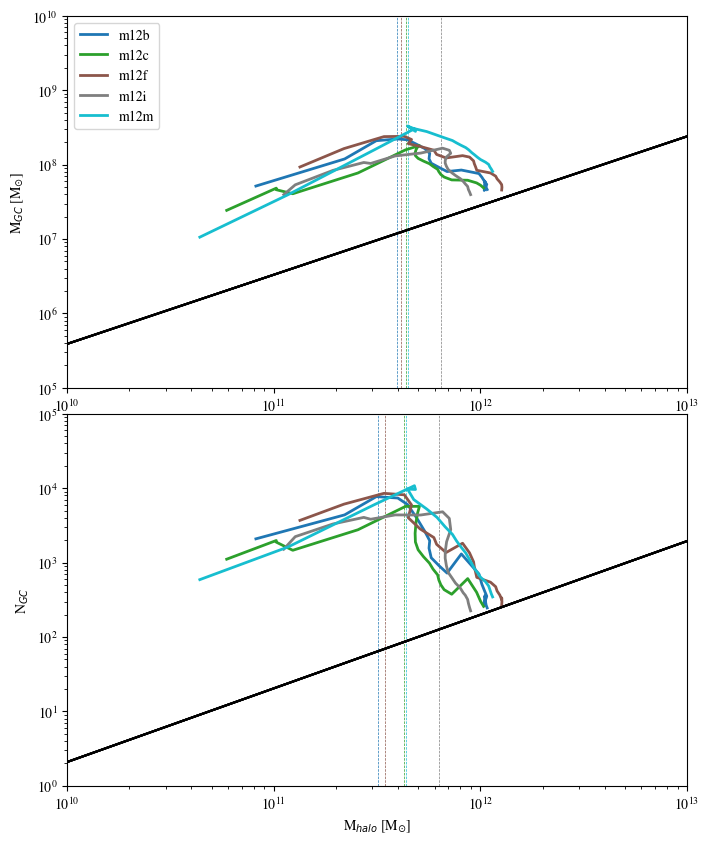

In [9]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 10))
plt.subplots_adjust(hspace=0.07)

for i, sim in enumerate(sim_lst):
    gc_prop_dict = sim_plt_dict[sim]

    mvirs = gc_prop_dict["host"]["mvir"]
    gcmass_mean = gc_prop_dict["host"]["mas_avg"]
    gccnts_mean = gc_prop_dict["host"]["cnt_avg"]

    axs[0].plot(mvirs, gcmass_mean, c=colors[i], label=sim, lw=2)

    axs[0].set_xscale("log")
    axs[0].set_yscale("log")

    axs[0].set_xlabel(r"M$_{halo}$ [M$_{\odot}$]")
    axs[0].set_ylabel(r"M$_{GC}$ [M$_{\odot}$]")

    logx = np.arange(10, 16.5, 0.5)
    x = 10**logx
    x12 = x * 10**-12
    logx12 = np.log10(x12)
    logy = 7.45 + 0.93 * logx12
    y = 10**logy

    # from Chen & Gnedin 2023
    axs[0].plot(x, y, c="k")

    logy1 = -9.58 + 0.99 * logx
    y1 = 10**logy1

    axs[1].plot(mvirs, gccnts_mean, c=colors[i], label=sim, lw=2)

    # from Burkert & Forbes 2020
    axs[1].plot(x, y1, c="k")

    axs[1].set_xscale("log")
    axs[1].set_yscale("log")

    axs[1].set_xlabel(r"M$_{halo}$ [M$_{\odot}$]")
    axs[1].set_ylabel(r"N$_{GC}$")

    # for grp in gc_prop_dict["groups"].keys():
    #     mvirs = gc_prop_dict["groups"][grp]["mvir"]
    #     gcmass_mean = gc_prop_dict["groups"][grp]["mas_avg"]
    #     gccnts_mean = gc_prop_dict["groups"][grp]["cnt_avg"]

    #     axs[0].plot(mvirs, gcmass_mean, c=colors[i], label=sim, lw=1)
    #     axs[1].plot(mvirs, gccnts_mean, c=colors[i], label=sim, lw=1)

axs[0].set_xlim(10**10, 10**13)
axs[1].set_xlim(10**10, 10**13)

axs[0].set_ylim(10**5, 10**10)
axs[1].set_ylim(10**0, 10**5)

axs[0].legend(loc="upper left")


to_dict = {sim: {"mas": {"x": None, "y": None}, "cnt": {"x": None, "y": None}} for sim in sim_lst}


for sim in sim_lst:
    gc_prop_dict = sim_plt_dict[sim]

    Mhalo = gc_prop_dict["host"]["mvir"]
    time = gc_prop_dict["time"]
    Mgc = gc_prop_dict["host"]["mas_avg"]
    Ngc = gc_prop_dict["host"]["cnt_avg"]

    # ====================
    # M_GC turning point
    # ====================
    mask = np.isfinite(Mhalo) & np.isfinite(Mgc) & (Mgc > 0) & (Mhalo > 0)

    logM = np.log10(Mhalo[mask])
    logMgc = np.log10(Mgc[mask])
    time_v = time[mask]

    # sort (required for inverse interp)
    order = np.argsort(logM)
    logM, logMgc, time_v = logM[order], logMgc[order], time_v[order]

    fMgc = interp1d(logM, logMgc, kind="linear", fill_value="extrapolate")
    ftime = interp1d(logM, time_v, kind="linear", fill_value=np.nan)

    logM_fine = np.linspace(logM.min(), logM.max(), 300)
    logMgc_fine = fMgc(logM_fine)
    logMgc_smooth = gaussian_filter1d(logMgc_fine, sigma=2)

    idx = np.nanargmax(logMgc_smooth)

    to_dict[sim]["mas"]["x"] = 10.0 ** logM_fine[idx]
    to_dict[sim]["mas"]["y"] = 10.0 ** logMgc_smooth[idx]
    to_dict[sim]["mas"]["t"] = ftime(logM_fine[idx])

    # ====================
    # N_GC turning point
    # ====================
    mask = np.isfinite(Mhalo) & np.isfinite(Ngc) & (Ngc > 0) & (Mhalo > 0)

    logM = np.log10(Mhalo[mask])
    logNgc = np.log10(Ngc[mask])
    time_v = time[mask]

    order = np.argsort(logM)
    logM, logNgc, time_v = logM[order], logNgc[order], time_v[order]

    fNgc = interp1d(logM, logNgc, kind="linear", fill_value="extrapolate")
    ftime = interp1d(logM, time_v, kind="linear", fill_value=np.nan)

    logNgc_fine = fNgc(logM_fine)
    logNgc_smooth = gaussian_filter1d(logNgc_fine, sigma=2)

    idx = np.nanargmax(logNgc_smooth)

    to_dict[sim]["cnt"]["x"] = 10.0 ** logM_fine[idx]
    to_dict[sim]["cnt"]["y"] = 10.0 ** logNgc_smooth[idx]
    to_dict[sim]["cnt"]["t"] = ftime(logM_fine[idx])


for i, sim in enumerate(sim_lst):
    axs[0].axvline(to_dict[sim]["mas"]["x"], c=colors[i], ls="dashed", zorder=0, lw=0.5)
    axs[1].axvline(to_dict[sim]["cnt"]["x"], c=colors[i], ls="dashed", zorder=0, lw=0.5)


In [10]:
sim = "m12m"

np.log10(to_dict[sim]["cnt"]["x"]), np.log10(to_dict[sim]["cnt"]["y"]), to_dict[sim]["cnt"]["t"]

(np.float32(11.642196), np.float64(3.97200328021662), array(4.45947951))

In [11]:
# sim_plt_ori_dict = {sim: None for sim in sim_lst}
# for sim in sim_lst:
#     print(sim)
#     halt = gc_utils.get_halo_tree(sim, sim_dir)
#     host_tid = sim_data[sim]["halo"]

#     gc_prop_dict = get_gc_prop_origins(sim, sim_dict, halt, host_tid)
#     sim_plt_ori_dict[sim] = gc_prop_dict

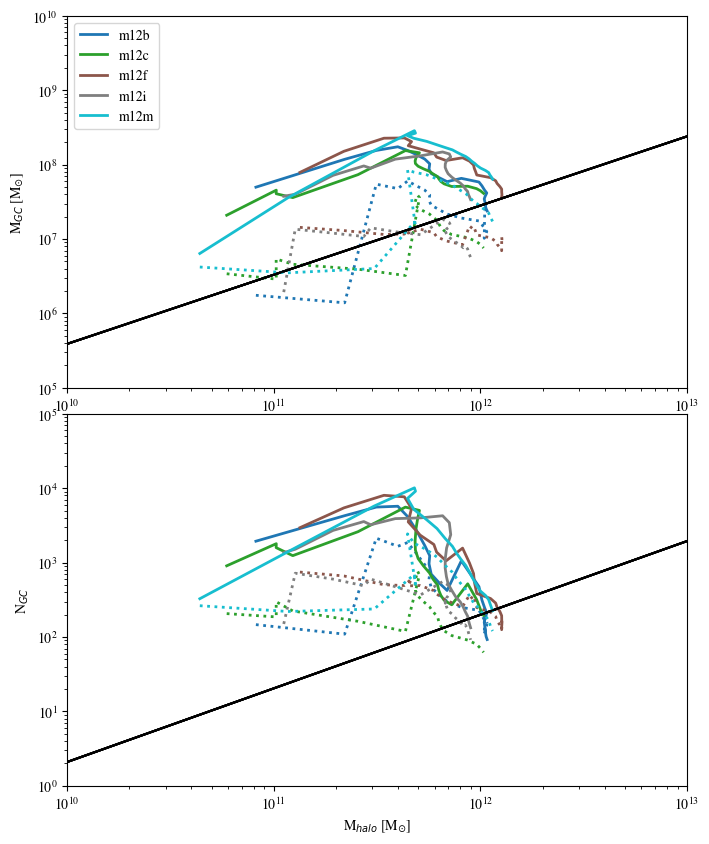

In [12]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 10))
plt.subplots_adjust(hspace=0.07)

for i, sim in enumerate(sim_lst):
    gc_prop_dict = sim_plt_ori_dict[sim]

    mvirs = gc_prop_dict["mvir"]
    in_gcmass_mean = gc_prop_dict["insitu"]["mas_avg"]
    in_gccnts_mean = gc_prop_dict["insitu"]["cnt_avg"]

    ex_gcmass_mean = gc_prop_dict["exsitu"]["mas_avg"]
    ex_gccnts_mean = gc_prop_dict["exsitu"]["cnt_avg"]

    axs[0].plot(mvirs, in_gcmass_mean, c=colors[i], label=sim, lw=2)
    axs[0].plot(mvirs, ex_gcmass_mean, c=colors[i], lw=2, ls="dotted")

    axs[0].set_xscale("log")
    axs[0].set_yscale("log")

    axs[0].set_xlabel(r"M$_{halo}$ [M$_{\odot}$]")
    axs[0].set_ylabel(r"M$_{GC}$ [M$_{\odot}$]")

    logx = np.arange(10, 16.5, 0.5)
    x = 10**logx
    x12 = x * 10**-12
    logx12 = np.log10(x12)
    logy = 7.45 + 0.93 * logx12
    y = 10**logy

    # from Chen & Gnedin 2023
    axs[0].plot(x, y, c="k")

    logy1 = -9.58 + 0.99 * logx
    y1 = 10**logy1

    axs[1].plot(mvirs, in_gccnts_mean, c=colors[i], label=sim, lw=2)
    axs[1].plot(mvirs, ex_gccnts_mean, c=colors[i], lw=2, ls="dotted")

    # from Burkert & Forbes 2020
    axs[1].plot(x, y1, c="k")

    axs[1].set_xscale("log")
    axs[1].set_yscale("log")

    axs[1].set_xlabel(r"M$_{halo}$ [M$_{\odot}$]")
    axs[1].set_ylabel(r"N$_{GC}$")

    # for grp in gc_prop_dict["groups"].keys():
    #     mvirs = gc_prop_dict["groups"][grp]["mvir"]
    #     gcmass_mean = gc_prop_dict["groups"][grp]["mas_avg"]
    #     gccnts_mean = gc_prop_dict["groups"][grp]["cnt_avg"]

    #     axs[0].plot(mvirs, gcmass_mean, c=colors[i], label=sim, lw=1)
    #     axs[1].plot(mvirs, gccnts_mean, c=colors[i], label=sim, lw=1)

axs[0].set_xlim(10**10, 10**13)
axs[1].set_xlim(10**10, 10**13)

axs[0].set_ylim(10**5, 10**10)
axs[1].set_ylim(10**0, 10**5)

axs[0].legend(loc="upper left")

# Mass Distributions

In [13]:
def gc_masses_at_time(tim, select, t_snp, m_snp):
    """
    Return array of GC masses at time tim.
    """
    masses = []

    for i in np.where(select)[0]:
        x = t_snp[i]
        y = m_snp[i]

        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() >= 2:
            masses.append(np.interp(tim, x[mask], y[mask]))

    return np.asarray(masses)


def mass_histogram(ax, sim, sim_dict, tim, density=False):
    ax.clear()
    bins = 10 ** np.linspace(2, 7.1, 52)

    hist_dict = {"insum": None, "exsum": None, "n": 0}

    for it_id in sim_dict[sim].keys():
        dat = sim_dict[sim][it_id]

        tfor = dat["tfor"]
        tdis = dat["tdis"].copy()
        tdis[tdis == -1] = np.inf
        tacc = dat["tacc"]

        t_snp = dat["t_snp"]
        m_snp = dat["m_snp"]

        alive = (tfor <= tim) & (tim < tdis)
        inmw = tacc <= tim
        insitu = dat["acc"]

        in_select = alive & inmw & insitu
        ex_select = alive & inmw & ~insitu

        in_masses = gc_masses_at_time(tim, in_select, t_snp, m_snp)
        ex_masses = gc_masses_at_time(tim, ex_select, t_snp, m_snp)

        hin, _ = np.histogram(in_masses, bins=bins)
        hex, _ = np.histogram(ex_masses, bins=bins)

        if hist_dict["insum"] is None:
            hist_dict["insum"] = hin.astype(float)
            hist_dict["exsum"] = hex.astype(float)
        else:
            hist_dict["insum"] += hin
            hist_dict["exsum"] += hex

        hist_dict["n"] += 1

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    widths = bins[1:] - bins[:-1]

    insum = hist_dict["insum"] / hist_dict["n"]
    exsum = hist_dict["exsum"] / hist_dict["n"]

    if density:
        insum = insum / np.sum(insum * widths)
        exsum = exsum / np.sum(exsum * widths)

    ax.step(bins[:-1], insum, where="post", color="r", label="in-situ")
    ax.fill_between(bins[:-1], insum, step="post", alpha=0.5, color="r")

    ax.step(bins[:-1], exsum, where="post", color="b", label="ex-situ")
    ax.fill_between(bins[:-1], exsum, step="post", alpha=0.5, color="b")

    ax.set_xscale("log")
    ax.set_xlabel(r"$M_{\rm GC}\,[M_\odot]$")
    ax.set_ylabel("Number" if not density else "PDF")
    ax.legend()

    ax.set_xlim(10**2, 10**7)
    ax.set_ylim(0)

    text = sim + "\n" + "t = " + str(np.round(tim, 2)) + " Gyr"

    ax.text(
        0.04,
        0.94,
        text,
        transform=ax.transAxes,
        color="k",
        ha="left",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="white",
        ),
    )

In [14]:
def gif_wrapping(
    plot_func,
    param_name,
    param_values,
    gif_path,
    fixed_kwargs=None,
    interval=200,
    dpi=150,
    figsize=(8, 6),
):
    """
    Generic animation wrapper.
    """

    fixed_kwargs = fixed_kwargs or {}

    fig, ax = plt.subplots(figsize=figsize)

    def update(value):
        kwargs = fixed_kwargs.copy()
        kwargs[param_name] = value
        plot_func(ax=ax, **kwargs)
        return (ax,)

    anim = FuncAnimation(fig, update, frames=param_values, interval=interval, blit=False)

    anim.save(gif_path, writer=PillowWriter(fps=1000 // interval), dpi=dpi)
    plt.close(fig)

In [15]:
sim = "m12m"
tims = np.arange(1, 14, 0.5)

gif_path = "../data/results/" + sim + "_mass_splits_105.gif"
gif_wrapping(
    plot_func=mass_histogram,
    param_name="tim",
    param_values=tims,
    gif_path=gif_path,
    fixed_kwargs=dict(sim=sim, sim_dict=sim_dict),
    interval=250,
)

In [16]:
ratio_dict = {sim: {"in": None, "ex": None} for sim in sim_lst}
tims = np.arange(1, 14, 0.1)
for sim in sim_lst:
    incnt = []
    excnt = []
    total = []
    for it_id in sim_dict[sim].keys():
        dat = sim_dict[sim][it_id]

        tfor = dat["tfor"]
        tdis = dat["tdis"].copy()
        tdis[tdis == -1] = np.inf
        tacc = dat["tacc"]

        t_snp = dat["t_snp"]
        m_snp = dat["m_snp"]

        incnt_i = []
        excnt_i = []
        total_i = []
        for tim in tims:
            alive = (tfor <= tim) & (tim < tdis)
            inmw = tacc <= tim
            insitu = dat["acc"]

            incnt_i.append(np.sum(alive & inmw & insitu))
            excnt_i.append(np.sum(alive & inmw & ~insitu))
            total_i.append(np.sum(alive & inmw))

        incnt.append(np.asarray(incnt_i))
        excnt.append(np.asarray(excnt_i))
        total.append(np.asarray(total_i))

    inrat = []
    exrat = []
    for i, _ in enumerate(incnt):
        inrat.append(incnt[i] / total[i])
        exrat.append(excnt[i] / total[i])

    inrat_avg = np.mean(inrat, axis=0)
    exrat_avg = np.mean(exrat, axis=0)

    ratio_dict[sim]["in"] = inrat_avg
    ratio_dict[sim]["ex"] = exrat_avg

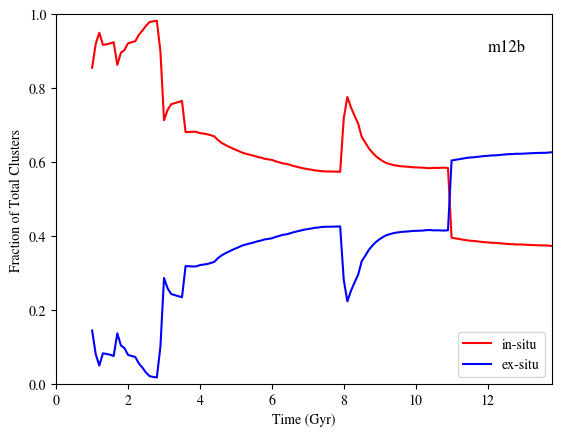

In [17]:
sim = "m12b"

plt.plot(tims, ratio_dict[sim]["in"], c="r", label="in-situ")
plt.plot(tims, ratio_dict[sim]["ex"], c="b", label="ex-situ")

plt.ylabel("Fraction of Total Clusters")
plt.xlabel("Time (Gyr)")

plt.text(12, 0.90, sim, ha="left", fontsize=12)
plt.xlim(0, timez0)
plt.ylim(0, 1)
plt.legend()

In [18]:
def extrapolate_gc_mass_post_now(t_snp, m_snp, t_future, t_now, n_last=10):
    """
    Extrapolate GC mass to t_future using the last n_last
    available points prior to t_now.
    """
    n_gc = m_snp.shape[0]
    m_future = np.full(n_gc, np.nan)

    for i in range(n_gc):
        t = t_snp[i]
        m = m_snp[i]

        mask = np.isfinite(t) & np.isfinite(m) & (t <= t_now)
        if mask.sum() < max(2, n_last):
            continue

        idx = np.where(mask)[0][-n_last:]

        a, b = np.polyfit(t[idx], m[idx], 1)
        m_pred = a * t_future + b

        m_future[i] = max(m_pred, 0.0)

    return m_future

In [19]:
ratio_dict_future = {sim: {"dt": None, "in": None, "ex": None} for sim in sim_lst}

dt_grid = np.linspace(0, timez0 / 2, 20)  # Gyr into the future

for sim in sim_lst:
    inrat_all_dt = []
    exrat_all_dt = []

    for dt in dt_grid:
        t_future = timez0 + dt

        inrat_iter = []
        exrat_iter = []

        for it_id in sim_dict[sim].keys():
            dat = sim_dict[sim][it_id]
            smsk = dat["s_tz0"]

            tfor = dat["tfor"][smsk]
            tacc = dat["tacc"][smsk]
            insitu = dat["acc"][smsk]

            t_snp = dat["t_snp"][smsk]
            m_snp = dat["m_snp"][smsk]

            m_future = extrapolate_gc_mass_post_now(t_snp, m_snp, t_future, timez0)

            alive = (tfor <= t_future) & (m_future > 0)
            inmw = tacc <= t_future
            select = alive & inmw

            tot = np.sum(select)
            if tot == 0:
                continue

            incnt = np.sum(select & insitu)
            excnt = np.sum(select & ~insitu)

            inrat_iter.append(incnt / tot)
            exrat_iter.append(excnt / tot)

        inrat_all_dt.append(np.nanmean(inrat_iter))
        exrat_all_dt.append(np.nanmean(exrat_iter))

    ratio_dict_future[sim]["dt"] = dt_grid
    ratio_dict_future[sim]["in"] = np.asarray(inrat_all_dt)
    ratio_dict_future[sim]["ex"] = np.asarray(exrat_all_dt)

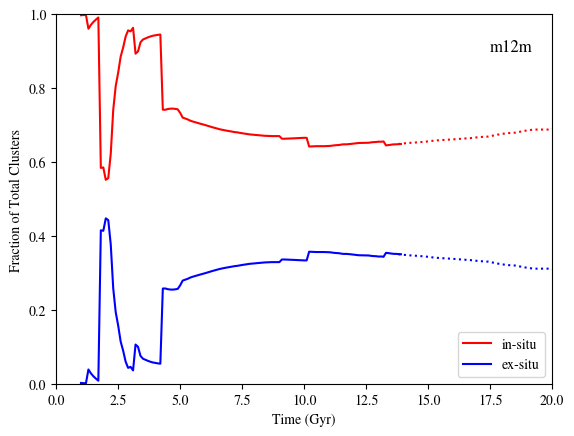

In [20]:
sim = "m12m"

plt.plot(tims, ratio_dict[sim]["in"], c="r", label="in-situ")
plt.plot(tims, ratio_dict[sim]["ex"], c="b", label="ex-situ")

plt.plot(timez0 + ratio_dict_future[sim]["dt"], ratio_dict_future[sim]["in"], c="r", ls="dotted")
plt.plot(timez0 + ratio_dict_future[sim]["dt"], ratio_dict_future[sim]["ex"], c="b", ls="dotted")

plt.ylabel("Fraction of Total Clusters")
plt.xlabel("Time (Gyr)")

plt.text(17.5, 0.90, sim, ha="left", fontsize=12)
plt.xlim(0, 20)
plt.ylim(0, 1)
plt.legend(loc="lower right")

# Missing Population

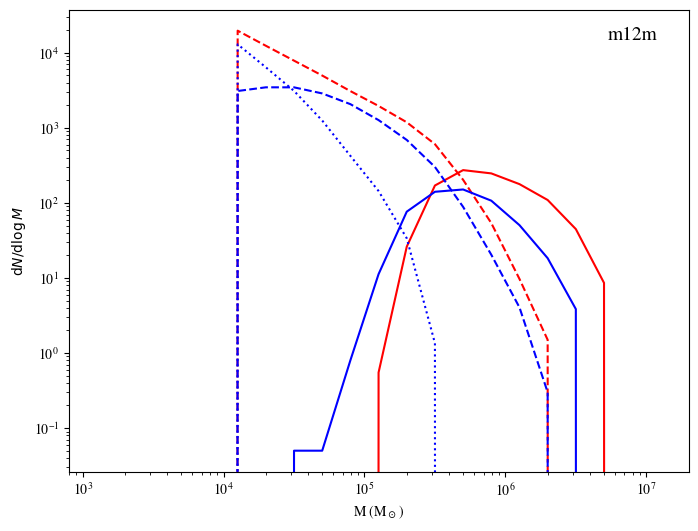

In [21]:
sim = "m12m"
plt_type = "mfor"  # "mfor" or "pz0"

# --- binning ---
if plt_type == "mfor":
    bins = np.linspace(3, 7.2, 22)
    xlabel = r"M (M$_\odot$)"
    ylabel = r"$\mathrm{d}N / \mathrm{d}\log M$"
else:
    bins = np.linspace(0.2, 5, 25)
    xlabel = r"$\mathrm{P}_{z=0}$ (Myr)"
    ylabel = r"$\mathrm{d}N / \mathrm{P}_{z=0}$"

# --- accumulator ---
hist_sum = {k: None for k in range(5)}
n_it = 0

for it_id in sim_dict[sim].keys():
    dat = sim_dict[sim][it_id]

    acc = dat["acc"]
    mfor = dat["m_tfo"]
    pz0 = dat["t_tz0"]
    stz0 = dat["s_tz0"]
    saflg = dat["sa_flag"]
    tdis = dat["tdis"].copy()
    tdis[tdis == -1] = np.inf

    in_s = acc & stz0
    in_d = acc & ~stz0
    ex_s = ~acc & stz0
    ex_db = ~acc & ~stz0 & ~saflg
    ex_da = ~acc & ~stz0 & saflg

    msk_lst = [in_s, in_d, ex_s, ex_db, ex_da]

    for i, msk in enumerate(msk_lst):
        y = mfor[msk] if plt_type == "mfor" else pz0[msk]
        y = y[np.isfinite(y) & (y > 0)]

        if len(y) == 0:
            continue

        logy = np.log10(y)
        N, edges = np.histogram(logy, bins=bins)
        dlogy = np.diff(edges)
        dNdlogy = N / dlogy

        if hist_sum[i] is None:
            hist_sum[i] = dNdlogy.astype(float)
        else:
            hist_sum[i] += dNdlogy

    n_it += 1

lab_lst = [
    "in-situ survive",
    "in-situ disrupted",
    "ex-situ survive",
    "ex-situ disrupted pre accretion",
    "ex-situ disrupted post accretion",
]
col_lst = ["r", "r", "b", "b", "b"]
ls_lst = ["-", "--", "-", "dotted", "--"]

logy_centers = 0.5 * (bins[1:] + bins[:-1])
y_centers = 10**logy_centers

plt.figure(figsize=(8, 6))

for i in range(5):
    if hist_sum[i] is None:
        continue

    avg = hist_sum[i] / n_it
    plt.plot(
        y_centers,
        avg,
        c=col_lst[i],
        ls=ls_lst[i],
        label=lab_lst[i],
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel(xlabel)
plt.ylabel(ylabel)

if plt_type == "mfor":
    plt.text(8e6, 1.5e4, sim, fontsize=14, ha="center")
else:
    plt.text(5e4, 0.8e4, sim, fontsize=14, ha="center")

# plt.legend(loc="upper right", facecolor="white", framealpha=1)

# Destruction Contours

In [22]:
def plot_cont_bounding(ax, sim, tcut, in_msk=True, cont_level=0.95):
    ax.clear()

    ############################################################
    logx_grid = np.linspace(3, 7.2, 200)
    logy_grid = np.linspace(0, 4, 200)
    XX, YY = np.meshgrid(logx_grid, logy_grid)
    grid_positions = np.vstack([XX.ravel(), YY.ravel()])
    ############################################################

    ############################################################
    Z0_list = []
    Z1_list = []
    # for it_id in sim_dict[sim].keys():
    for it_id in ["it001"]:
        # print(it_id)
        acc = sim_dict[sim][it_id]["acc"] == in_msk
        mfor = sim_dict[sim][it_id]["m_tfo"]
        pz0 = sim_dict[sim][it_id]["t_tz0"]
        sz0 = sim_dict[sim][it_id]["s_tz0"]
        tdis = sim_dict[sim][it_id]["tdis"].copy()
        tfor = sim_dict[sim][it_id]["tfor"]
        tdis[tdis == -1] = np.inf

        tfor_msk = tfor <= tcut
        # tfor_msk = tfor <= np.inf
        tdis_msk = tdis <= tcut

        x0 = mfor[tfor_msk & tdis_msk & acc]
        y0 = pz0[tfor_msk & tdis_msk & acc]
        x1 = mfor[tfor_msk & ~tdis_msk & acc]
        y1 = pz0[tfor_msk & ~tdis_msk & acc]

        log_x0 = np.log10(x0)
        log_y0 = np.log10(y0)
        log_x1 = np.log10(x1)
        log_y1 = np.log10(y1)

        kde0 = gaussian_kde(np.vstack([log_x0, log_y0]))
        Z0 = kde0(grid_positions).reshape(XX.shape)
        Z0 /= Z0.sum()  # equal weight per iteration
        Z0_list.append(Z0)

        kde1 = gaussian_kde(np.vstack([log_x1, log_y1]))
        Z1 = kde1(grid_positions).reshape(XX.shape)
        Z1 /= Z1.sum()  # equal weight per iteration
        Z1_list.append(Z1)

    if in_msk:
        col = "r"
    else:
        col = "b"

    Z0_avg = np.mean(Z0_list, axis=0)
    Z0_avg[XX <= 4] = 0
    Z0f = Z0_avg.ravel()
    idx = np.argsort(Z0f)[::-1]
    Z0s = Z0f[idx]
    Z0_cdf = np.cumsum(Z0s)
    Z0_cdf /= Z0_cdf[-1]
    level = Z0s[np.searchsorted(Z0_cdf, cont_level)]
    ax.contour(10**XX, 10**YY, Z0_avg, levels=[level], colors="grey", linewidths=2)

    Z1_avg = np.mean(Z1_list, axis=0)
    Z1_avg[XX <= 4] = 0
    Z1f = Z1_avg.ravel()
    idx = np.argsort(Z1f)[::-1]
    Z1s = Z1f[idx]
    Z1_cdf = np.cumsum(Z1s)
    Z1_cdf /= Z1_cdf[-1]
    level = Z1s[np.searchsorted(Z1_cdf, cont_level)]
    ax.contour(10**XX, 10**YY, Z1_avg, levels=[level], colors=col, linewidths=2)

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlim(10**3.9, 10**7)
    ax.set_ylim(10**0.3, 10**4.1)

    ax.set_xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$")
    ax.set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")

    surv = Line2D([0], [0], color=col, linewidth=2, label="Surviving Population")
    disr = Line2D([0], [0], color="grey", linewidth=2, label="Disrupted Population")
    ax.legend(handles=[surv, disr], frameon=False)

    text = sim + "\n" + "t = " + str(np.round(tcut, 2)) + " Gyr"

    ax.text(
        0.04,
        0.94,
        text,
        transform=ax.transAxes,
        color="k",
        ha="left",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="white",
        ),
    )


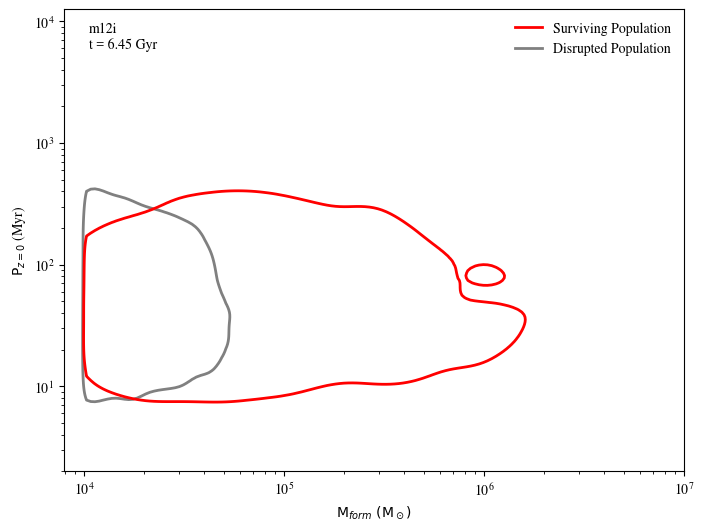

In [23]:
sim = "m12i"
in_msk = True
cont_level = 0.95
tcut = 6.45

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))
plot_cont_bounding(ax, sim, tcut, in_msk=True, cont_level=0.95)

In [24]:
# sim = "m12m"
# in_msk = True
# cont_level = 0.95

# tcuts = np.arange(2, 14, 0.5)

# gif_path = "../data/results/" + sim + "_tcut.gif"
# gif_wrapping(
#     plot_func=plot_cont_bounding,
#     param_name="tcut",
#     param_values=tcuts,
#     gif_path=gif_path,
#     fixed_kwargs=dict(sim=sim, in_msk=in_msk, cont_level=cont_level),
#     interval=250,
# )

# Mass Growth of Galaxies

Text(0, 0.5, 'M$_{halo}$ [M$_{\\odot}$]')

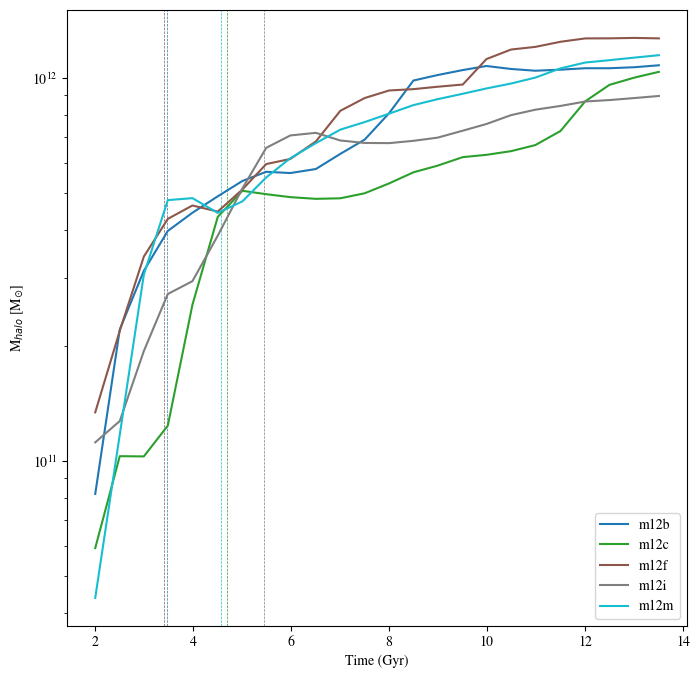

In [33]:
plt.figure(figsize=(8, 8))

for i, sim in enumerate(sim_lst):
    gc_prop_dict = sim_plt_dict[sim]

    Mhalo = gc_prop_dict["host"]["mvir"]
    time = gc_prop_dict["time"]

    plt.plot(time, Mhalo, c=colors[i], label=sim)
    plt.axvline(to_dict[sim]["mas"]["t"], c=colors[i], ls="dashed", zorder=0, lw=0.5)

plt.yscale("log")
plt.legend(loc="lower right")

plt.xlabel("Time (Gyr)")
plt.ylabel(r"M$_{halo}$ [M$_{\odot}$]")

In [41]:
cnt_dict = {sim: {"in": None, "ex": None, "to": None} for sim in sim_lst}
tims = np.arange(1, 14, 0.05)
for sim in sim_lst:
    incnt = []
    excnt = []
    total = []
    for it_id in sim_dict[sim].keys():
        dat = sim_dict[sim][it_id]

        tfor = dat["tfor"]
        tdis = dat["tdis"].copy()
        tdis[tdis == -1] = np.inf
        tacc = dat["tacc"]

        t_snp = dat["t_snp"]
        m_snp = dat["m_snp"]

        incnt_i = []
        excnt_i = []
        total_i = []
        for tim in tims:
            alive = (tfor <= tim) & (tim < tdis)
            inmw = tacc <= tim
            insitu = dat["acc"]

            incnt_i.append(np.sum(alive & inmw & insitu))
            excnt_i.append(np.sum(alive & inmw & ~insitu))
            total_i.append(np.sum(alive & inmw))

        incnt.append(np.asarray(incnt_i))
        excnt.append(np.asarray(excnt_i))
        total.append(np.asarray(total_i))

    incnt_avg = np.mean(incnt, axis=0)
    excnt_avg = np.mean(excnt, axis=0)
    total_avg = np.mean(total, axis=0)

    cnt_dict[sim]["in"] = incnt_avg
    cnt_dict[sim]["ex"] = excnt_avg
    cnt_dict[sim]["to"] = total_avg

(10, np.float64(15415.119922778964))

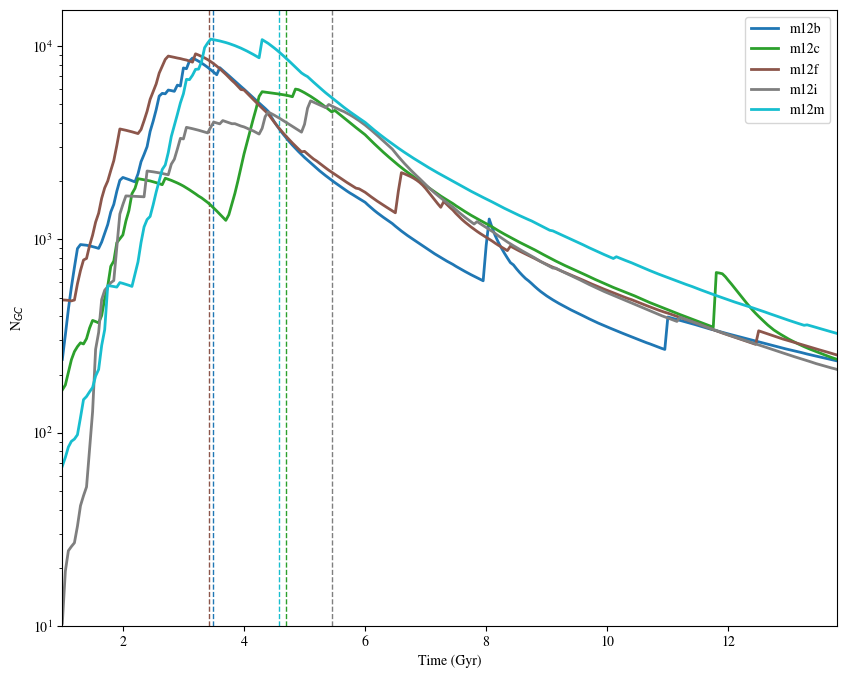

In [57]:
plt.figure(figsize=(10, 8))

for i, sim in enumerate(sim_lst):
    plt.plot(tims, cnt_dict[sim]["to"], c=colors[i], lw=2, label=sim)
    plt.axvline(to_dict[sim]["mas"]["t"], c=colors[i], ls="dashed", zorder=0, lw=1)

plt.yscale("log")
plt.legend(loc="upper right")

plt.xlabel("Time (Gyr)")
plt.ylabel(r"N$_{GC}$")

plt.xlim(1, timez0)
plt.ylim(10**1)

# Extra Relations

In [ ]:
for sim in sim_lst:
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    ghost_data = h5py.File(ghost_file, "r")

    sim_dict[sim] = {}
    for it_id in ghost_data.keys():
        src_dat = ghost_data[it_id]["source"]

In [62]:
src_dat.keys()

<KeysViewHDF5 ['feh', 'gcid', 'grpid', 'halo.r.avg', 'halo.r.avg.pre', 'halo.r.birth', 'halo_tfor', 'host.r.avg', 'host.r.avg.pos', 'host.r.avg.pre', 'host.r.birth', 'logm_tfor', 'logm_tz0', 'pidx_snap600', 'ptype', 'pxyz_snap600', 's_flag', 'sa_flag', 'snap_tacc', 'snap_tfor', 'snap_tforp', 'tacc', 'tdis', 'tfor', 'tideig.avg', 'tideig.avg.pos', 'tideig.avg.pre', 'torb_600', 'vxyz_snap600']>

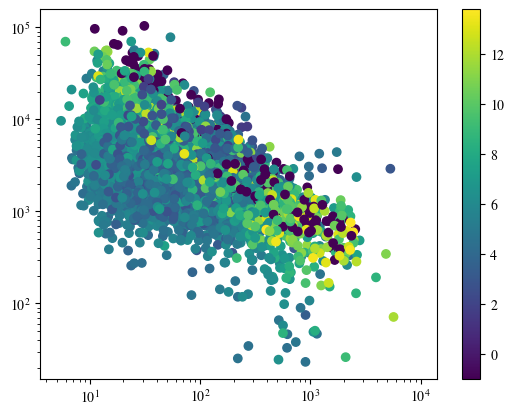

In [71]:
sim = "m12i"
it_id = "it001"

ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")
src_dat = ghost_data[it_id]["source"]

# x = 10 ** src_dat["logm_tfor"][()]
x = src_dat["torb_600"]
y = src_dat["tideig.avg.pos"]
c = src_dat["tdis"]

plt.scatter(x, y, c=c)
plt.colorbar()

plt.xscale("log")
plt.yscale("log")

# Galaxy Plots

In [88]:
def return_mass_plot(sim: str, sim_dir: str, smoothing: bool = True):
    all_data = sim_dir + sim + "/" + sim + "_res7100/snapshot_times.txt"
    all_snaps = pd.read_table(all_data, comment="#", header=None, sep=r"\s+")
    all_snaps.columns = [
        "index",
        "scale_factor",
        "redshift",
        "time_Gyr",
        "lookback_time_Gyr",
        "time_width_Myr",
    ]

    sim_code_file = sim_dir + "simulation_codes.json"
    with open(sim_code_file, "r") as file:
        sim_codes = json.load(file)
    main_halo = sim_codes[sim]["halo"]
    Ob = sim_codes[sim]["Ob"]
    Om = sim_codes[sim]["Om"]
    fb = Ob / Om

    halt = gc_utils.get_halo_tree(sim, sim_dir)

    halo_idx = np.where(halt["tid"] == main_halo)[0][0]
    dm_mass_z0 = halt["mass"][halo_idx]
    mass_z0 = dm_mass_z0 / (1 - fb)

    time_lst = [0]
    mass_ratio_lst = [0]
    dm_mass_lst = [0]
    mass_lst = [0]
    for snap in range(10, 601):
        time = all_snaps[all_snaps["index"] == snap]["time_Gyr"].values[0]

        halo_tid = gc_utils.get_halo_prog_at_snap(halt, main_halo, snap)
        halo_idx = np.where(halt["tid"] == halo_tid)[0][0]
        dm_mass = halt["mass"][halo_idx]
        mass = dm_mass / (1 - fb)
        mass_ratio = mass / mass_z0

        time_lst.append(time)
        mass_ratio_lst.append(mass_ratio)

        dm_mass_lst.append(dm_mass)
        mass_lst.append(mass)

    if smoothing:
        mass_ratio_lst = savgol_filter(mass_ratio_lst, window_length=50, polyorder=3)

    # grp_file = sim_dir + sim + "/" + "gc_groups.json"
    # with open(grp_file, "r") as file:
    #     grp_dict = json.load(file)
    # grp_lst = [int(grp) for grp in grp_dict[sim].keys() if int(grp) != 0]

    # acc_dict = {grp: {} for grp in grp_lst}
    # acc_dict = {int(grp): {} for grp in grp_dict[sim].keys() if int(grp) != 0}

    # for grp in acc_dict.keys():
    #     grp_idx = np.where(halt["tid"] == grp)[0][0]
    #     grp_snp = halt["snapshot"][grp_idx]
    #     grp_tim = all_snaps[all_snaps["index"] == grp_snp + 1]["time_Gyr"].values[0]
    #     acc_dict[grp] = grp_tim

    mass_dict = {"time": time_lst, "mass_ratio": mass_ratio_lst, "dm_mass": dm_mass_lst, "mass": mass_lst}

    return mass_dict

In [89]:
gal_dict = {sim: {} for sim in sim_lst}
for sim in sim_lst:
    mass_dict = return_mass_plot(sim, sim_dir, smoothing=True)
    gal_dict[sim] = mass_dict

Retrieving Halo Tree.....................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [01:12<00:00, 72.90s/it]


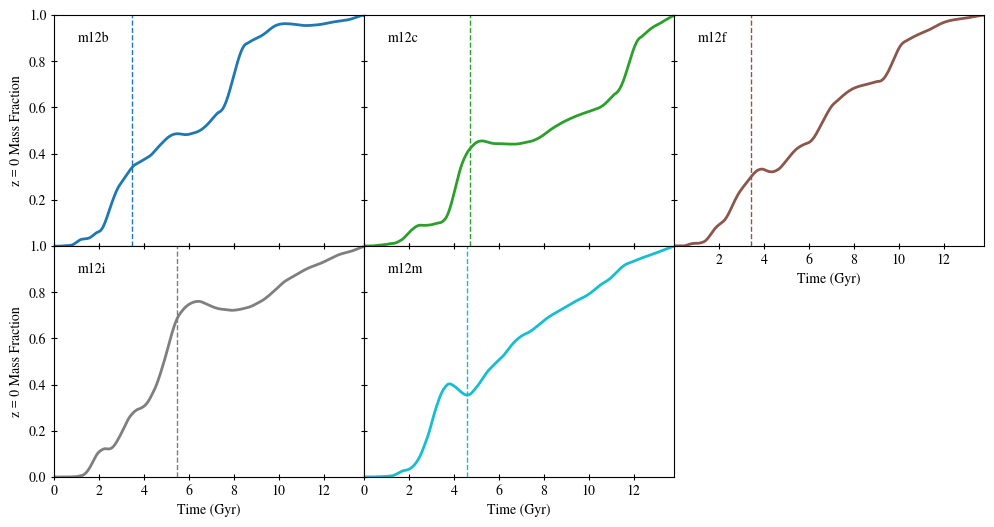

In [91]:
nrows = 2
ncols = 3

xticks = [0, 2, 4, 6, 8, 10, 12]
yticks = [0, 0.2, 0.4, 0.6, 0.8, 1]

cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in np.linspace(0, 1, len(sim_lst))]

fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=False, sharex=False)
plt.subplots_adjust(hspace=0, wspace=0)

for i, ax in enumerate(axs.flatten()):
    if i == len(sim_lst):
        ax.axis("off")
        continue
    sim = sim_lst[i]

    # mass_ratio_lst, time_lst, acc_dict = return_mass_plot(sim, sim_dir, smoothing=True)
    mass_ratio_lst = gal_dict[sim]["mass_ratio"]
    time_lst = gal_dict[sim]["time"]

    ax.plot(time_lst, mass_ratio_lst, c=colors[i], lw=2)
    ax.axvline(to_dict[sim]["mas"]["t"], c=colors[i], ls="dashed", zorder=0, lw=1)

    ax.set_xlim(0, np.max(time_lst))
    ax.set_ylim(0, 1)

    ax.text(
        0.075,
        0.9,
        sim,
        horizontalalignment="left",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(
            facecolor="white",  # background color
            edgecolor="none",  # no border
            boxstyle="round,pad=0.3",
        ),
    )

    if (i == 0) or (i == 3):
        ax.set_ylabel("z = 0 Mass Fraction")

        if i == 0:
            ax.set_yticks(yticks[1:])

    else:
        ax.set_yticklabels([])

    if i < 2:
        ax.set_xticklabels([])

    if i == 2:
        ax.set_xticks(xticks[1:])

    if i < 3:
        ax.tick_params(axis="x", which="major", direction="inout", bottom=True, top=False, length=4)
    else:
        ax.tick_params(axis="x", which="major", direction="inout", bottom=True, top=True, length=4)

    ax.tick_params(axis="y", which="major", direction="inout", left=True, right=False, length=4)

    if i in [2, 3, 4]:
        ax.set_xlabel("Time (Gyr)")

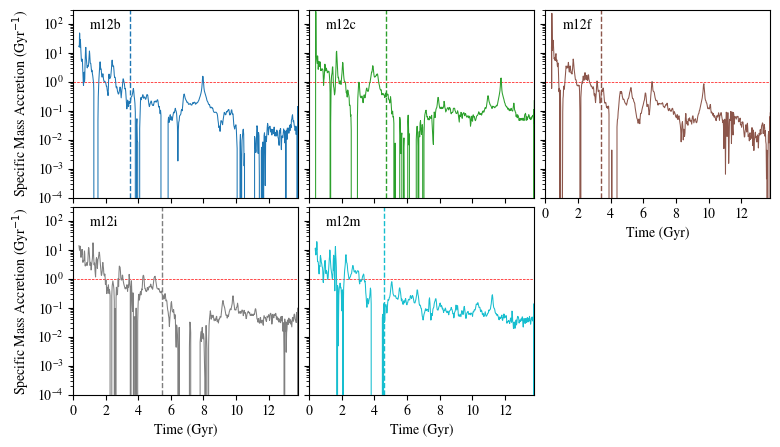

In [98]:
nrows = 2
ncols = 3

fig, axs = plt.subplots(nrows, ncols, figsize=(9, 5), sharey=False, sharex=False)
plt.subplots_adjust(hspace=0.05, wspace=0.05)


for i, ax in enumerate(axs.flatten()):
    if i > 4:
        ax.axis("off")
        continue

    sim = sim_lst[i]
    dm = np.gradient(gal_dict[sim]["mass"][1:], gal_dict[sim]["time"][1:])
    ax.plot(gal_dict[sim]["time"][1:], dm / gal_dict[sim]["mass"][1:], c=colors[i], lw=0.75, zorder=10)

    ax.axvline(to_dict[sim]["mas"]["t"], c=colors[i], ls="dashed", zorder=0, lw=1)

    ax.set_xlim(0, np.max(gal_dict[sim]["time"]))
    ax.set_ylim(10**-4, 300)
    ax.set_yscale("log")
    ax.set_xticks([0, 2, 4, 6, 8, 10, 12])

    ax.text(
        0.075,
        0.92,
        sim,
        horizontalalignment="left",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(
            facecolor="white",  # background color
            edgecolor="none",  # no border
            boxstyle="round,pad=0.3",
        ),
    )

    if (i == 0) or (i == 3):
        ax.set_ylabel("Specific Mass Accretion (Gyr$^{-1}$)")

        # if i == 0:
        #     ax.set_yticks(yticks[1:])

    else:
        ax.set_yticklabels([])

    if i < 2:
        ax.set_xticklabels([])

    if i in [2, 3, 4]:
        ax.set_xlabel("Time (Gyr)")

    p3 = 1
    ax.plot([0, np.max(gal_dict[sim]["time"])], [p3, p3], c="r", ls="--", lw=0.5)
